In [2]:
# Import Librraies
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
X = np.random.rand(100, 1)
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [4]:
# import pandas 
import pandas as pd

In [5]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y 

In [6]:
df

,X,y
0,0.374540,0.425193
1,0.950714,2.696623
2,0.731994,1.612033
3,0.598658,0.975797
4,0.156019,0.062042
...,...,...
95,0.493796,0.690712
96,0.522733,0.815894
97,0.427541,0.565432
98,0.025419,0.015773


In [9]:
# mean of the target column
df['y_pred1'] = df['y'].mean()

# Find the residual
df['res1'] = df['y'] - df['y_pred1']

In [10]:
df

,X,y,y_pred1,res1
0,0.374540,0.425193,0.926001,-0.500807
1,0.950714,2.696623,0.926001,1.770622
2,0.731994,1.612033,0.926001,0.686033
3,0.598658,0.975797,0.926001,0.049797
4,0.156019,0.062042,0.926001,-0.863959
...,...,...,...,...
95,0.493796,0.690712,0.926001,-0.235289
96,0.522733,0.815894,0.926001,-0.110107
97,0.427541,0.565432,0.926001,-0.360569
98,0.025419,0.015773,0.926001,-0.910228


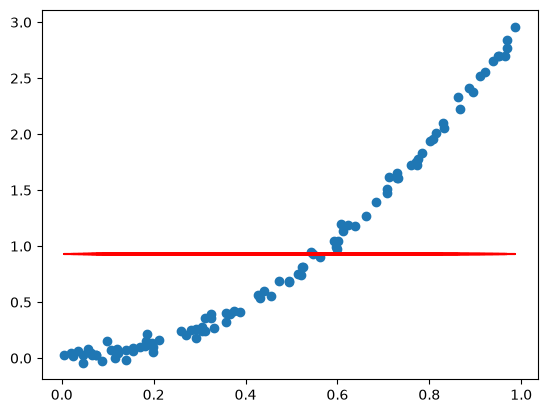

In [17]:
# plot a scatter
plt.scatter(df['X'], df['y'])
# plot a mean line
plt.plot(df['X'], df['y_pred1'], color='red')

In [19]:
# model_2
# import DecisionTreeClassifier from sklearn.tree
from sklearn.tree import DecisionTreeRegressor

tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

# Fit the model
tree1.fit(df['X'].values.reshape(100, 1), df['res1'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

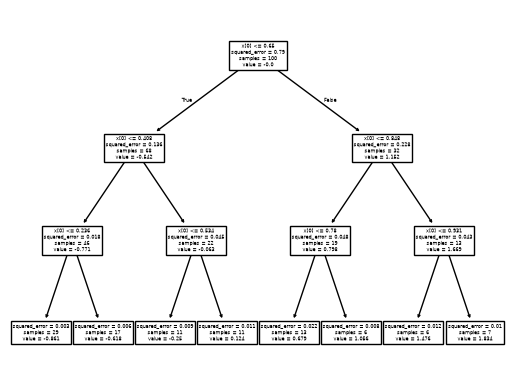

In [21]:
# plot tree
from sklearn.tree import plot_tree
plot_tree(tree1)

# show the tree
plt.show()

In [23]:
# generating X_test
X_test = np.linspace(-0.5, 0.5, 500)

In [26]:
# Predict the values using the model_2
y_pred1 = 0.926001 + tree1.predict(X_test.reshape(500, 1))

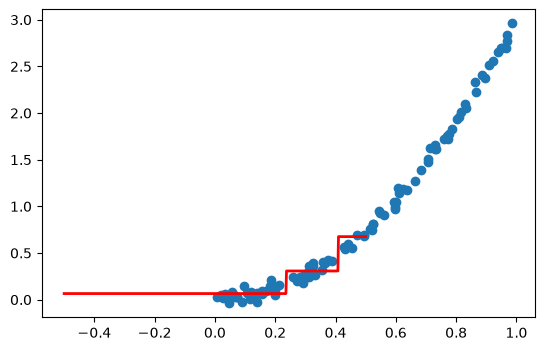

In [27]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
plt.plot(X_test, y_pred1, linewidth=2, color='red')

plt.scatter(df['X'], df['y'])

In [36]:
# Calculate y_pred 
df['y_pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))

# Calculate res2
df['res2'] = df['y'] - df['y_pred2']

**Train Model 3**

In [41]:
# Create a object of DecisionTreeRegressor
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

# Fit the model 
tree2.fit(df['X'].values.reshape(100, 1), df['res2'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.7272727272727273, 0.9285714285714286, 'x[0] <= 0.978\nsquared_error = 0.009\nsamples = 100\nvalue = 0.661'),
 Text(0.6363636363636364, 0.7857142857142857, 'x[0] <= 0.711\nsquared_error = 0.009\nsamples = 99\nvalue = 0.659'),
 Text(0.6818181818181819, 0.8571428571428572, 'True  '),
 Text(0.45454545454545453, 0.6428571428571429, 'x[0] <= 0.65\nsquared_error = 0.008\nsamples = 72\nvalue = 0.65'),
 Text(0.36363636363636365, 0.5, 'x[0] <= 0.604\nsquared_error = 0.006\nsamples = 68\nvalue = 0.661'),
 Text(0.2727272727272727, 0.35714285714285715, 'x[0] <= 0.534\nsquared_error = 0.005\nsamples = 64\nvalue = 0.653'),
 Text(0.18181818181818182, 0.21428571428571427, 'x[0] <= 0.505\nsquared_error = 0.005\nsamples = 57\nvalue = 0.661'),
 Text(0.09090909090909091, 0.07142857142857142, 'squared_error = 0.005\nsamples = 53\nvalue = 0.653'),
 Text(0.2727272727272727, 0.07142857142857142, 'squared_error = 0.001\nsamples = 4\nvalue = 0.765'),
 Text(0.36363636363636365, 0.21428571428571427, 'squar

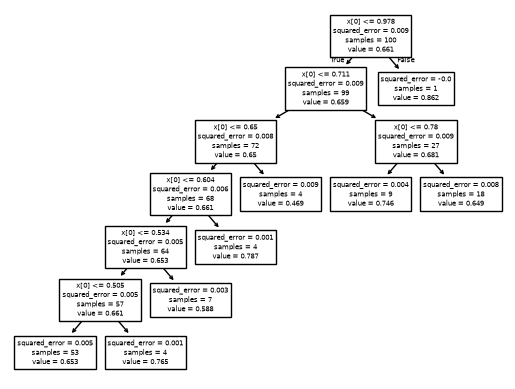

In [42]:
# plot_decision_tree
plot_tree(tree2)

In [47]:
# y_pred 
y_pred = 0.265458 + sum(
    regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1, tree2]
)

Text(0.5, 1.0, 'X vs y')

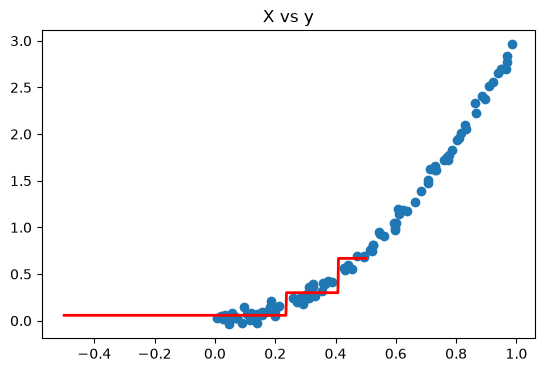

In [48]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2, color='red')
plt.scatter(df['X'], df['y'])
# plt title 
plt.title('X vs y')

In [50]:
X_test.reshape(500, 1)  # Convert into the 2D array

array([[-0.5       ],
       [-0.49799599],
       [-0.49599198],
       [-0.49398798],
       [-0.49198397],
       [-0.48997996],
       [-0.48797595],
       [-0.48597194],
       [-0.48396794],
       [-0.48196393],
       [-0.47995992],
       [-0.47795591],
       [-0.4759519 ],
       [-0.4739479 ],
       [-0.47194389],
       [-0.46993988],
       [-0.46793587],
       [-0.46593186],
       [-0.46392786],
       [-0.46192385],
       [-0.45991984],
       [-0.45791583],
       [-0.45591182],
       [-0.45390782],
       [-0.45190381],
       [-0.4498998 ],
       [-0.44789579],
       [-0.44589178],
       [-0.44388778],
       [-0.44188377],
       [-0.43987976],
       [-0.43787575],
       [-0.43587174],
       [-0.43386774],
       [-0.43186373],
       [-0.42985972],
       [-0.42785571],
       [-0.4258517 ],
       [-0.4238477 ],
       [-0.42184369],
       [-0.41983968],
       [-0.41783567],
       [-0.41583166],
       [-0.41382766],
       [-0.41182365],
       [-0

In [54]:
# Define a function gradient_boosting

def gradient_boost(X, y, number, lr, count=1, regs=[], foo=None):
    if number == 0:
        return
    else:
        # Do_Gradient_Boosting

        if count > 1:
            y = y - regs[-1].predict(X)
        else:
            foo = y

    tree_reg = DecisionTreeRegressor(max_leaf_nodes=5, random_state=42)
    tree_reg.fit(X, y)

    # append at the end
    regs.append(tree_reg)

    # linespace the number
    x1 = np.linspace(-0.5, 0.5, 500)

    # predict the values
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:,0], foo, 'r.')
    plt.show()
    
    gradient_boost(X, y, number-1, lr, count+1, regs, foo=foo)

5


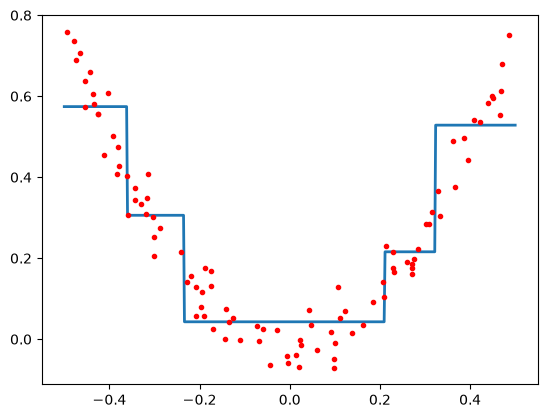

4


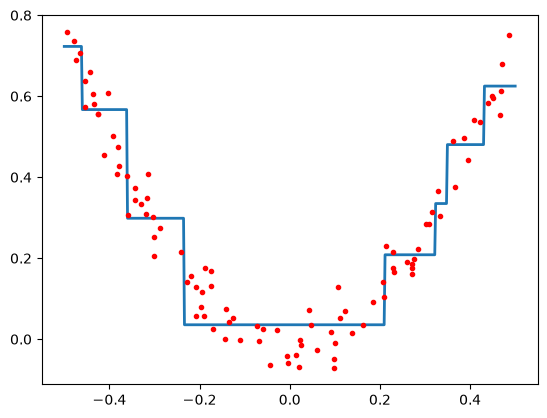

3


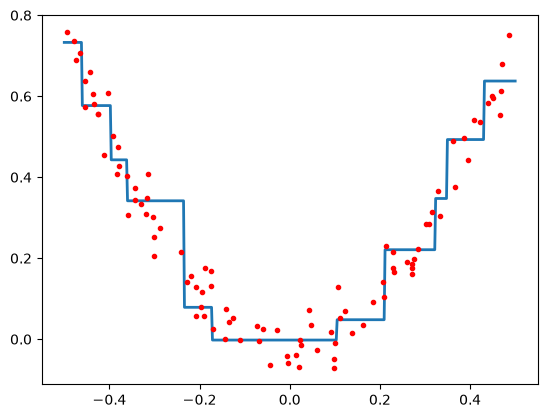

2


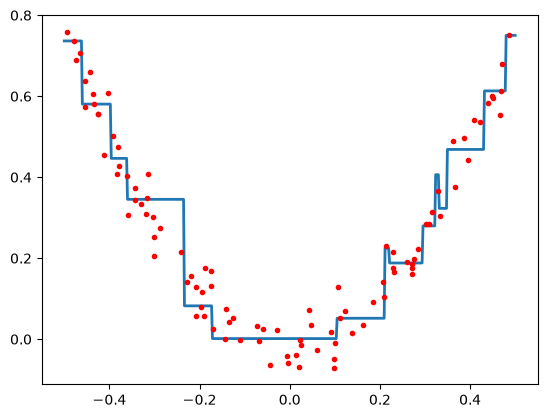

1


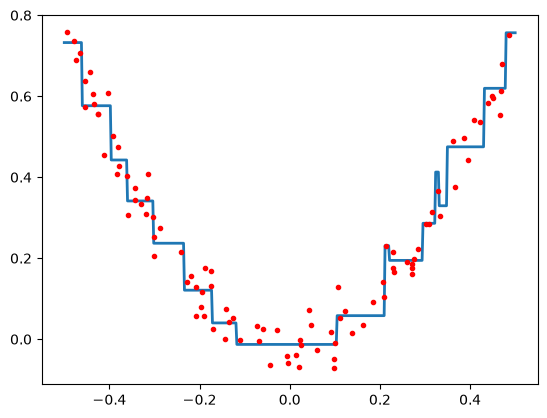

In [55]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)